# MATH 189: San Diego Airbnb Short-Term Residential Occupancy (STRO) Ordinance Analysis

---

**Group 37**: Anthony Mitine, Alan Tran, Jimmy Ying, James Xu

**Question**: Did the city of San Diego's May 2023 STRO ordinance, which eliminated nearly 50% of short-term rentals across the city, cause a statistically significant decrease in long-term rent prices, and was this effect stronger in ZIP codes with higher pre-ordinance Airbnb listing density?

**Hypothesis**: Our null hypothesis is that the implementation of short-term rental caps did not have a differential effect on the average Airbnb listing price between both high-density and low-density areas. Our alternative hypothesis is that the implementation of short-term rental caps did have a differential effect on the average Airbnb listing price between both high-density and low-density areas.

**Data**: To conduct our analysis of both the short-term and long-term housing markets, we analyzed and combined two separate datasets:
* *InsideAirbnb Data:* We utilized publicly available, point-in-time snapshot data of Airbnb listings in San Diego, directly downloading the CSV files from insideairbnb.com. We selected one pre-ordinance dataset (March 2023) and one post-ordinance dataset (June 2025). Key features analyzed included price, neighborhood, latitude, longitude, and room type.
* *Zillow Observed Rent Index (ZORI):* To measure the externalized effect on the long-term residential housing market, we imported longitudinal ZORI data for San Diego ZIP codes, filtering for the corresponding January 2023 and January 2025 timeframes.

## Data Loading and Preprocessing

We first import pre-ordinance and post-ordinance datasets, selected arbitrarily to be March 2023 and June 2025. We  filter the listings to isolate `Entire home/apt` properties, as the May 2023 STRO ordinance specifically targeted whole-home rentals, and perform data cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set visual style for all plots
sns.set_theme(style="whitegrid")

# Load the raw datasets
df_2023 = pd.read_csv('2023_03_mar_listings.csv')
df_2025 = pd.read_csv('2025_21_june_listings.csv')

cols_to_keep = ['id', 'last_scraped', 'neighbourhood_cleansed','latitude', 'longitude', 'room_type', 'price']

df_2023 = df_2023[cols_to_keep].copy()
df_2025 = df_2025[cols_to_keep].copy()

# time variable
df_2023['Time_Period'] = 'Pre-Ordinance'
df_2025['Time_Period'] = 'Post-Ordinance'

df = pd.concat([df_2023, df_2025], ignore_index=True)

#  cleaning the price column into ints
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# drop invalid prices
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

# We only care about whole-home units for the sake of this project
df = df[df['room_type'] == 'Entire home/apt']
df = df.rename(columns={'neighbourhood_cleansed': 'neighbourhood'})

df.head()

,id,last_scraped,neighbourhood,latitude,longitude,room_type,price,Time_Period
0,610920,2023-03-25,La Jolla,32.81244,-117.26835,Entire home/apt,725.0,Pre-Ordinance
1,6,2023-03-25,North Hills,32.75522,-117.12873,Entire home/apt,349.0,Pre-Ordinance
2,29967,2023-03-25,Pacific Beach,32.80751,-117.25760,Entire home/apt,225.0,Pre-Ordinance
3,1166766,2023-03-25,Bay Park,32.78337,-117.19911,Entire home/apt,794.0,Pre-Ordinance
4,1167130,2023-03-25,Old Town,32.74569,-117.18702,Entire home/apt,1250.0,Pre-Ordinance


## EDA: Defining Density Groups & Handling Outliers
To test our hypothesis, we classify neighborhoods into `High-Density` and `Low-Density` groups.  We calculate the total listings per neighborhood in March 2023 and split them at the median. Since rental price data is right skewed by expensive, luxurious properties, we will filter out the top 1% of price outliers.

In [2]:
df_pre = df[df['Time_Period'] == 'Pre-Ordinance']

# count total number of listings per neighborhood in 2023
neighborhood_counts = df_pre['neighbourhood'].value_counts()
median_density = neighborhood_counts.median()

# list of neighborhoods that fall strictly above the median
high_density_hoods = neighborhood_counts[neighborhood_counts > median_density].index.tolist()
def assign_density(hood):
    if hood in high_density_hoods:
        return 'High-Density'
    else:
        return 'Low-Density'

# add new column
df['Density_Group'] = df['neighbourhood'].apply(assign_density)

print(df['Density_Group'].value_counts())



# remove expensive outliers
df_filtered = df[df['price'] <= df['price'].quantile(0.99)].copy()

print(f"99th Percentile Price Threshold: ${df['price'].quantile(0.99)}")
print(f"Listings remaining after filtering: {len(df_filtered)}")

Density_Group
High-Density    19373
Low-Density      1357
Name: count, dtype: int64
99th Percentile Price Threshold: $1999.0
Listings remaining after filtering: 20526


## Visualizing Price Distributions
With our outlier-filtered dataset (`df_filtered`), we will use boxplots and overlapping histograms to compare the variance and skewness between High-Density and Low-Density areas across both time periods.

Since our Density Groups are highly imbalanced (which is expected, as Airbnbs cluster in specific tourist zones), we use a density statistic for our histogram. This normalizes the area under the curve for both groups, allowing us to accurately compare their underlying distributions regardless of the sheer volume of listings.

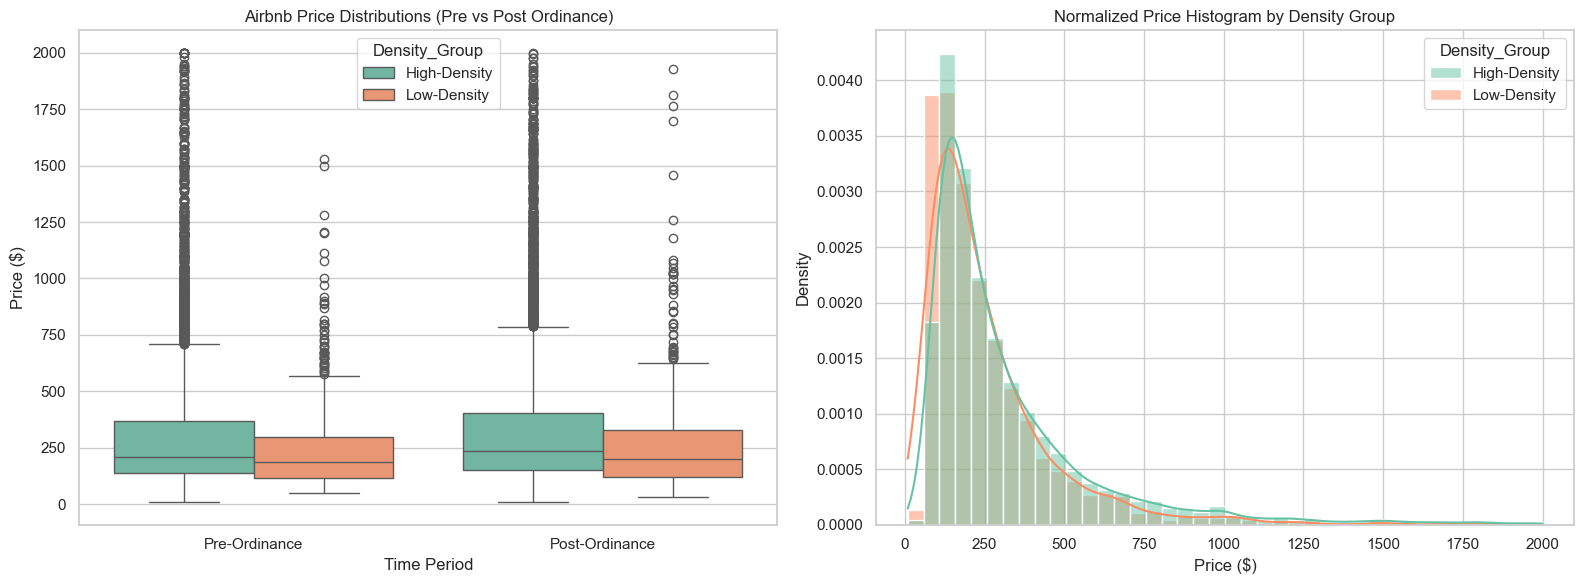

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=df_filtered, x='Time_Period', y='price', hue='Density_Group',
    palette='Set2', ax=axes[0])
axes[0].set_title('Airbnb Price Distributions (Pre vs Post Ordinance)')
axes[0].set_ylabel('Price ($)')
axes[0].set_xlabel('Time Period')

# Density Histogram
sns.histplot(data=df_filtered, x='price', hue='Density_Group', stat='density',
    common_norm=False, kde=True, bins=40, alpha=0.5, palette='Set2', ax=axes[1])
axes[1].set_title('Normalized Price Histogram by Density Group')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

## Assessing Normality and Baseline Trends
Our initial histograms show a strong right-skew in the price data. To formally evaluate the normality assumption required for our upcoming regression models, we will generate a Quantile-Quantile (QQ) plot.

Additionally, we will plot the Empirical Cumulative Distribution Functions (ECDFs) for both density groups. This provides a clear visualization of the baseline differences in cumulative probability and serves as the visual foundation for the nonparametric Two-Sample Kolmogorov-Smirnov test, should our regression assumptions be irreparably violated by the heavy-tailed data.

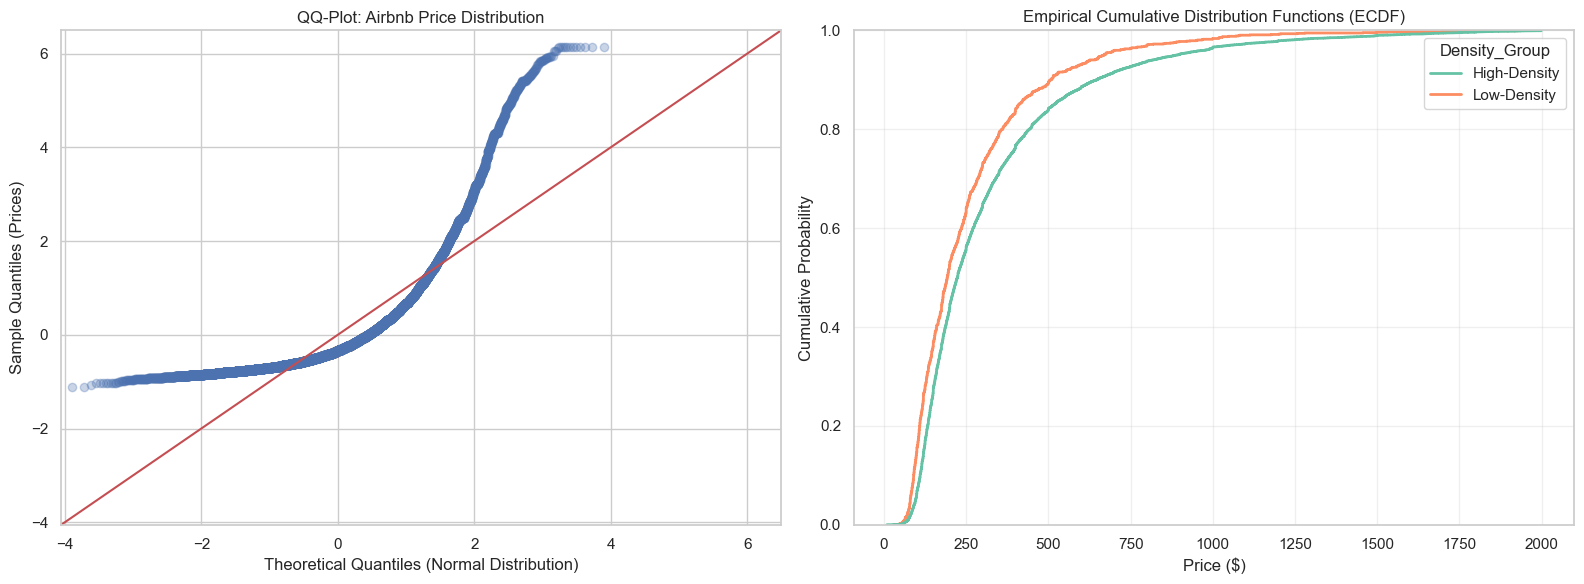

In [4]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# QQ-Plot
sm.qqplot(df_filtered['price'], line='45', fit=True, ax=axes[0], alpha=0.3)
axes[0].set_title('QQ-Plot: Airbnb Price Distribution')
axes[0].set_ylabel('Sample Quantiles (Prices)')
axes[0].set_xlabel('Theoretical Quantiles (Normal Distribution)')

# Empirical Cumulative Distribution Function (ECDF)
sns.ecdfplot(data=df_filtered, x='price', hue='Density_Group', palette='Set2',
    linewidth=2, ax=axes[1])
axes[1].set_title('Empirical Cumulative Distribution Functions (ECDF)')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We see that the QQ plot also shows that the distribution of AirBnb prices is heavily skewed to the right, meaning the vast majority of Airbnbs are cheaply-to-moderately priced, but there is a long tail of extremely expensive luxury outliers.

## Log-Transformation and Model Refinement

Based on the observed right-skew in the QQ-plot, we will transform the `price` variable using a natural logarithm. This helps satisfy the OLS assumption of normality and allows us to interpret the interaction effect as a percentage change.

In [5]:
# log transformation of price

df_filtered['log_price'] = np.log(df_filtered['price'])

print("Original price summary:")
print(df_filtered['price'].describe())

print("\nLog(price) summary:")
print(df_filtered['log_price'].describe())

df_filtered[['price', 'log_price']].head()

Original price summary:
count    20526.000000
mean       314.970817
std        274.676823
min          9.000000
25%        144.000000
50%        220.000000
75%        381.750000
max       1999.000000
Name: price, dtype: float64

Log(price) summary:
count    20526.000000
mean         5.490876
std          0.687572
min          2.197225
25%          4.969813
50%          5.393628
75%          5.944765
max          7.600402
Name: log_price, dtype: float64


,price,log_price
0,725.0,6.586172
1,349.0,5.855072
2,225.0,5.416100
3,794.0,6.677083
4,1250.0,7.130899


## Verifying the Log Transformation

Before running the regression, we re-visualize the distribution of `log_price` to confirm it is approximately normal.

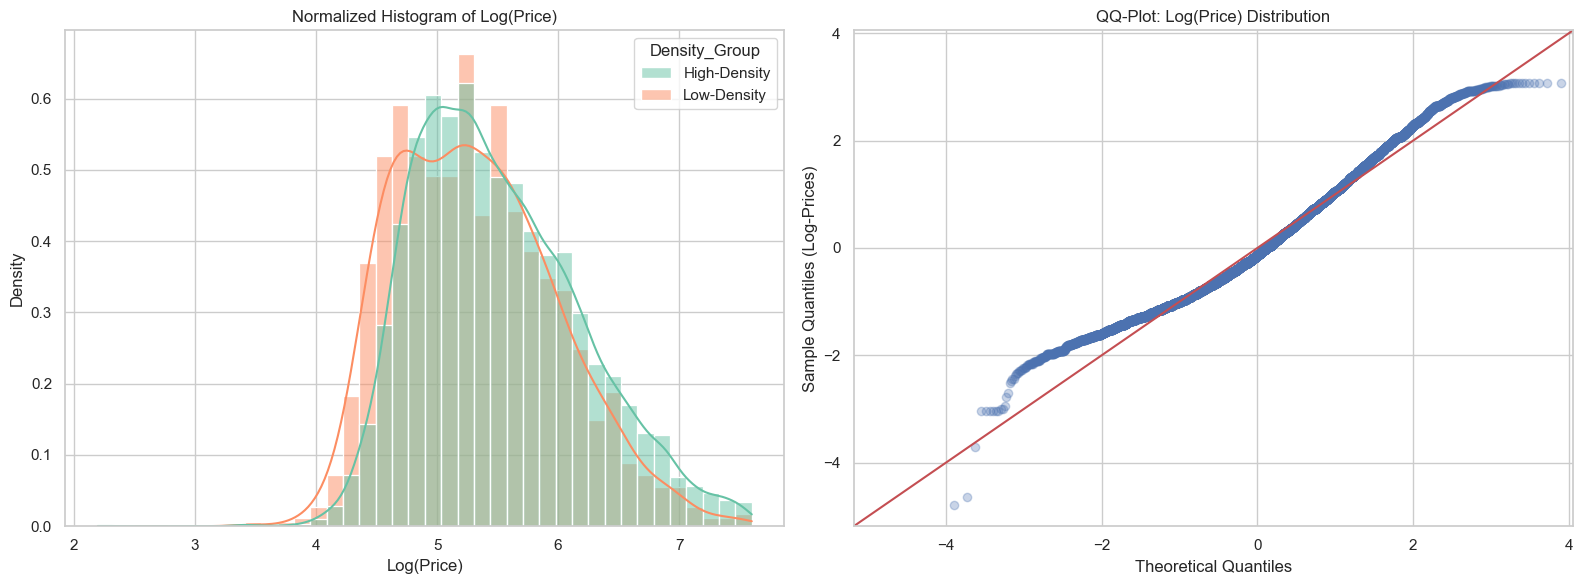

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-Price Histogram
sns.histplot(data=df_filtered, x='log_price', hue='Density_Group', stat='density',
             common_norm=False, kde=True, bins=40, palette='Set2', ax=axes[0])
axes[0].set_title('Normalized Histogram of Log(Price)')
axes[0].set_xlabel('Log(Price)')

# Log-Price QQ-Plot
sm.qqplot(df_filtered['log_price'], line='45', fit=True, ax=axes[1], alpha=0.3)
axes[1].set_title('QQ-Plot: Log(Price) Distribution')
axes[1].set_ylabel('Sample Quantiles (Log-Prices)')

plt.tight_layout()
plt.show()

Now, we attempt to fit a Multiple Linear Regression, with an interaction term of the two variables. We know that if the p-value for this interaction term is statistically significant (p < 0.05), it indicates that the STRO ordinance had a differential effect on Airbnb prices between high-density and low-density neighborhoods, allowing us to reject the null hypothesis.

In [7]:
# Apply the natural log transformation
df_filtered['log_price'] = np.log(df_filtered['price'])

# Prepare dummy variables
df_model = pd.get_dummies(df_filtered, columns=['Density_Group', 'Time_Period'], drop_first=True)

# Rename for clarity: High-Density is the reference by default if we dropped first,
# but let's ensure we know what the dummies represent.
df_model = df_model.rename(columns={
    'Density_Group_Low-Density': 'is_Low_Density',
    'Time_Period_Pre-Ordinance': 'is_Pre_Ordinance'
})

# Define variables for the model
y_log = df_model['log_price']
# Interaction term: (1 if Low-Density AND Pre-Ordinance, 0 otherwise)
X_log = df_model[['is_Low_Density', 'is_Pre_Ordinance']].copy()
X_log['Interaction'] = X_log['is_Low_Density'] * X_log['is_Pre_Ordinance']
X_log = sm.add_constant(X_log)

# Fit the Log-Linear OLS Model
log_model = sm.OLS(y_log, X_log.astype(float))
log_results = log_model.fit()

print(log_results.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     58.50
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.20e-37
Time:                        19:34:32   Log-Likelihood:                -21348.
No. Observations:               20526   AIC:                         4.270e+04
Df Residuals:                   20522   BIC:                         4.274e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.5494      0.007  

## Residual Analysis

We check the residuals of the log-transformed model to ensure the transformation fixed the distribution issues.

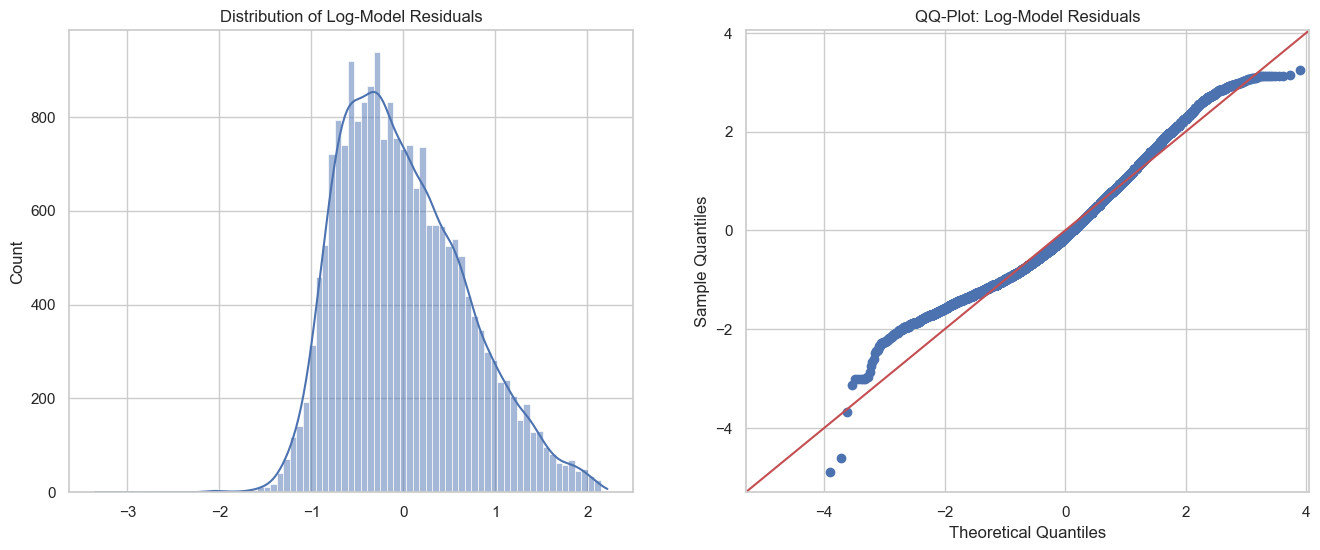

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Residual Distribution
sns.histplot(log_results.resid, kde=True, ax=ax[0])
ax[0].set_title('Distribution of Log-Model Residuals')

# QQ-Plot of Residuals
sm.qqplot(log_results.resid, line='45', fit=True, ax=ax[1])
ax[1].set_title('QQ-Plot: Log-Model Residuals')

plt.show()

## Visualizing the Interaction (Parallel Trends)

To better understand the high p-value, we can plot the mean log-prices for both groups across the two time periods. If the lines are roughly parallel, it confirms the lack of a differential impact.

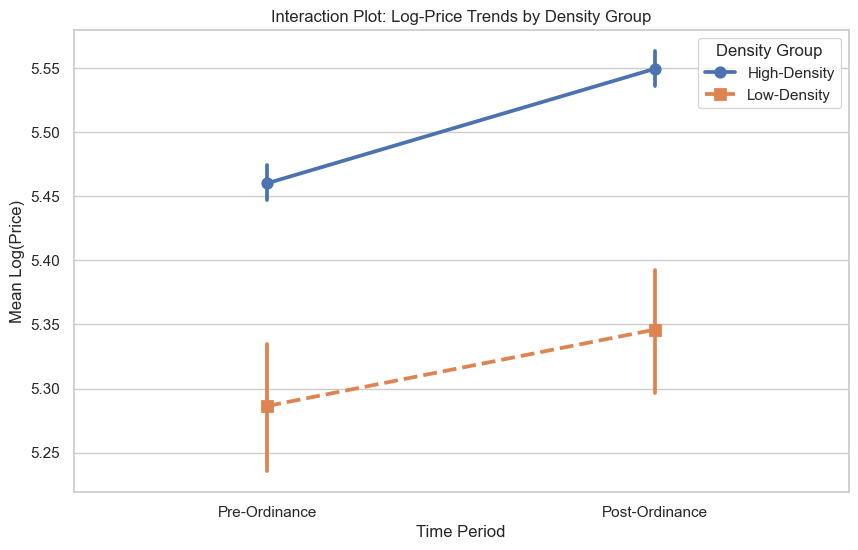

In [9]:
plt.figure(figsize=(10, 6))
sns.pointplot(data=df_filtered, x='Time_Period', y='log_price', hue='Density_Group',
              markers=['o', 's'], linestyles=['-', '--'])
plt.title('Interaction Plot: Log-Price Trends by Density Group')
plt.ylabel('Mean Log(Price)')
plt.xlabel('Time Period')
plt.legend(title='Density Group')
plt.show()

## Cook's Distance and ACF
To fulfill our regression assumptions, we evaluate influential points using Cook's Distance and check for autocorrelation in our residuals using an Autocorrelation Function (ACF) plot.

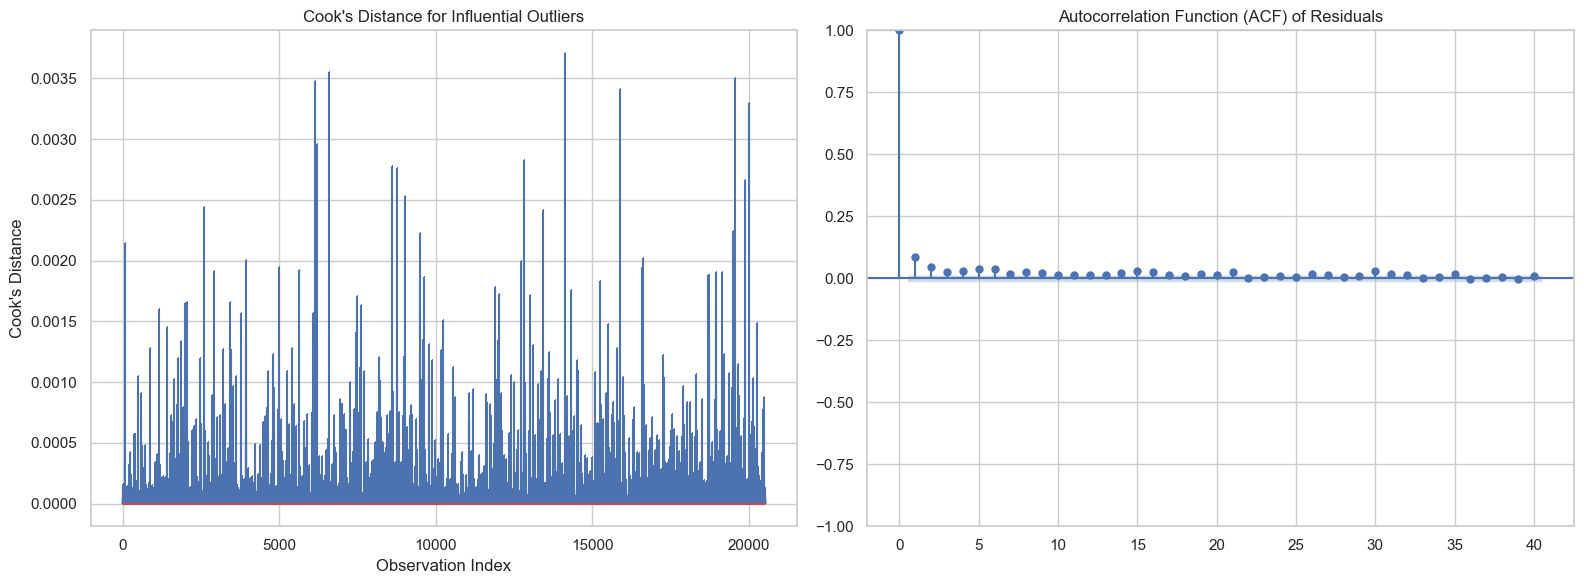

In [10]:
# Cook's Distance
influence = log_results.get_influence()
cooks_d = influence.cooks_distance[0]

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
ax[0].set_title("Cook's Distance for Influential Outliers")
ax[0].set_xlabel("Observation Index")
ax[0].set_ylabel("Cook's Distance")

# ACF Plot
sm.graphics.tsa.plot_acf(log_results.resid, lags=40, ax=ax[1])
ax[1].set_title("Autocorrelation Function (ACF) of Residuals")

plt.tight_layout()
plt.show()

## Non-parametric Testing Two-Sample Kolmogorov-Smirnov Test
Since our OLS model yielded a non-significant interaction and the residuals still show some non-normality, we use the KS test to compare the distributions of price changes.

In [11]:
# Kolmogorov-Smirnov Test
high_prices = df_filtered[df_filtered['Density_Group'] == 'High-Density']['price']
low_prices = df_filtered[df_filtered['Density_Group'] == 'Low-Density']['price']

ks_stat, p_value = stats.ks_2samp(high_prices, low_prices)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-Value: {p_value:.4e}")
if p_value < 0.05:
    print("Conclusion: Reject the null hypothesis. The distributions of prices in High-Density and Low-Density areas are statistically distinct.")
else:
    print("Conclusion: Fail to reject the null hypothesis.")

KS Statistic: 0.1173
P-Value: 1.8229e-15
Conclusion: Reject the null hypothesis. The distributions of prices in High-Density and Low-Density areas are statistically distinct.


## Conclusion & Interpretation of Short-Term Rent Data Analysis
Based on our analysis and regression modeling, we evaluate our primary hypotheses regarding the STRO ordinance's direct effect on Airbnb prices:

1. The interaction term between `Density_Group` and `Time_Period` yielded a coefficient of 0.0297 with a p-value of 0.444. Because our p-value is well above our 0.05 significance level, we fail to reject the null hypothesis.
2. While the STRO ordinance eliminated nearly 50% of the short-term rental supply, the OLS model indicates that this policy shock did not cause a statistically significant differential price change between high-density and low-density neighborhoods.
3. Since our residual diagnostics showed violations of normality, we applied the Two-Sample Kolmogorov-Smirnov test as a robust fallback. The KS test yielded a p-value of 1.8229e-15, leading us to reject the null hypothesis that the overall price distributions of high-density and low-density areas are identical. However, this confirms a baseline structural difference in the markets, not necessarily a differential shift caused by the ordinance.

The ordinance did not lead to a disproportionate price hike for the remaining Airbnbs in high-density tourist hotspots relative to low-density residential areas.

##  Long-Term Rent Data (ZORI)

While our previous analysis concluded that the STRO ordinance did not significantly alter the pricing structure of the short-term rental market itself, the primary legislative intent of the ordinance was to improve housing affordability for permanent residents. To determine if returning these short-term units to the residential market successfully lowered long-term housing costs, we must analyze longitudinal rent data.

We acquire and preprocess the Zillow Observed Rent Index (ZORI) dataset. To prepare the dataset for our regression model, we filter the data for San Diego and extract the specific pre- and post-ordinance groups (January 2023 and January 2025).

In [12]:
df_zori = pd.read_csv('Zip_zori_uc_sfrcondomfr_sm_month.csv')
df_zori.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2015-01-31,...,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,1382.485889,...,1736.951964,1745.514554,1741.294231,1732.244497,1719.408221,1715.273167,1695.842131,1683.702020,1664.191684,1660.034577
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2133.843943,2202.557545,2132.424394,2119.333333
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,1247.519342,...,1832.627905,1824.688732,1816.539786,1815.630208,1805.124318,1814.680790,1803.978163,1807.518808,1789.213615,1784.279693
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2725.504622,2750.000000
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,1099.478752,...,1586.090104,1591.663870,1590.368942,1585.461700,1576.546145,1570.756272,1571.819532,1565.203405,1557.190599,1547.429218


In [13]:
# Filter for San Diego
df_zori_sd = df_zori[df_zori['City'] == 'San Diego'].copy()

# Identify ID columns and date columns
id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
date_cols = [col for col in df_zori_sd.columns if col not in id_cols]

# Melt the dataframe to long format
df_zori_long = df_zori_sd.melt(
    id_vars=id_cols,
    value_vars=date_cols,
    var_name='Date',
    value_name='Rent'
)

# Convert Date to datetime objects
df_zori_long['Date'] = pd.to_datetime(df_zori_long['Date'])

# Rename RegionName to ZipCode for clarity
df_zori_long = df_zori_long.rename(columns={'RegionName': 'zip_code'})

# Create separate datasets for 2023-01-31 and 2025-01-31
df_zori_2023 = df_zori_long[df_zori_long['Date'] == '2023-01-31'].copy()
df_zori_2025 = df_zori_long[df_zori_long['Date'] == '2025-01-31'].copy()

print(f"Reshaped data for {df_zori_long['zip_code'].nunique()} San Diego ZIP codes.")
print(f"Rows in 2023-01 dataset: {len(df_zori_2023)}")
print(f"Rows in 2025-01 dataset: {len(df_zori_2025)}")
display(df_zori_2023.head())
display(df_zori_2025.head())

Reshaped data for 33 San Diego ZIP codes.
Rows in 2023-01 dataset: 33
Rows in 2025-01 dataset: 33


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,CountyName,Date,Rent
3168,96690,61,92154,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2682.553341
3169,96667,166,92126,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2731.418488
3170,96647,207,92105,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,1962.172456
3171,96656,271,92114,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2396.963929
3172,96657,414,92115,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2239.921859


,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,CountyName,Date,Rent
3960,96690,61,92154,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2910.729496
3961,96667,166,92126,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2874.158013
3962,96647,207,92105,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2089.258066
3963,96656,271,92114,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2648.433266
3964,96657,414,92115,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2537.960374


### Mapping Airbnb Density to ZIP Codes
We will now calculate which ZIP codes are 'High-Density' by mapping the neighborhood-level Airbnb density (from 2023) to the ZIP codes found in the ZORI dataset. We'll use the mean coordinates of listings in each neighborhood to approximate the ZIP code mapping if direct ZIP labels aren't in the Airbnb file, or simply aggregate by neighborhood and then merge.

In [14]:
# Use geopy for reverse geocoding
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter


geolocator = Nominatim(user_agent="sd_rent_analysis_v2")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=0.1)

# map neighborhoods to zip codes using airbnb dataset
nb_coords = df_pre.groupby('neighbourhood')[['latitude', 'longitude']].mean().reset_index()

def get_zip(lat, lon):
    try:
        location = geolocator.reverse((lat, lon), timeout=10)
        return location.raw.get('address', {}).get('postcode')
    except:
        return None

print("Mapping neighborhoods to ZIP codes...")
nb_coords['zip_code'] = nb_coords.apply(lambda x: get_zip(x['latitude'], x['longitude']), axis=1)


df_pre_mapped = df_pre.merge(nb_coords[['neighbourhood', 'zip_code']], on='neighbourhood', how='left')

# calculate density by zip code
zip_counts = df_pre_mapped['zip_code'].dropna().value_counts().reset_index()
zip_counts.columns = ['zip_code', 'listing_count']

# separate "high density" vs "low density" zip codes by comparing with median zip code density
zip_median = zip_counts['listing_count'].median()
zip_counts['Density_Group'] = zip_counts['listing_count'].apply(lambda x: 'High-Density' if x > zip_median else 'Low-Density')


zip_counts['zip_code'] = zip_counts['zip_code'].astype(str)
df_zori_2023['zip_code'] = df_zori_2023['zip_code'].astype(str)
df_zori_2025['zip_code'] = df_zori_2025['zip_code'].astype(str)

# merge density labels
df_zori_2023 = df_zori_2023.merge(zip_counts[['zip_code', 'Density_Group']], on='zip_code', how='inner')
df_zori_2025 = df_zori_2025.merge(zip_counts[['zip_code', 'Density_Group']], on='zip_code', how='inner')

Mapping neighborhoods to ZIP codes...


In [15]:
display(df_zori_2023)

,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,CountyName,Date,Rent,Density_Group
0,96647,207,92105,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,1962.172456,High-Density
1,96656,271,92114,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2396.963929,Low-Density
2,96657,414,92115,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2239.921859,High-Density
3,96671,599,92130,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,3775.509523,High-Density
4,96659,787,92117,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2616.121225,High-Density
5,96655,911,92113,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2083.445021,Low-Density
6,96653,960,92111,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2687.737762,High-Density
7,96669,1063,92128,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2783.956310,Low-Density
8,96643,1522,92101,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2832.029152,High-Density
9,96644,1622,92102,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2023-01-31,2262.535034,Low-Density


In [16]:
display(df_zori_2025)

,RegionID,SizeRank,zip_code,RegionType,StateName,State,City,Metro,CountyName,Date,Rent,Density_Group
0,96647,207,92105,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2089.258066,High-Density
1,96656,271,92114,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2648.433266,Low-Density
2,96657,414,92115,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2537.960374,High-Density
3,96671,599,92130,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,3939.262280,High-Density
4,96659,787,92117,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2714.422667,High-Density
5,96655,911,92113,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2240.418510,Low-Density
6,96653,960,92111,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2826.781008,High-Density
7,96669,1063,92128,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2947.125810,Low-Density
8,96643,1522,92101,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2836.120459,High-Density
9,96644,1622,92102,zip,CA,CA,San Diego,"San Diego-Chula Vista-Carlsbad, CA",San Diego County,2025-01-31,2338.501236,Low-Density


## Long-Term Rent Analysis (ZORI)
We combine our pre- and post-ordinance ZORI datasets. We will run an exploratory data analysis on the long-term rent prices and fit an OLS regression model with an interaction term to determine if rents decreased disproportionately in high-density Airbnb ZIP codes.

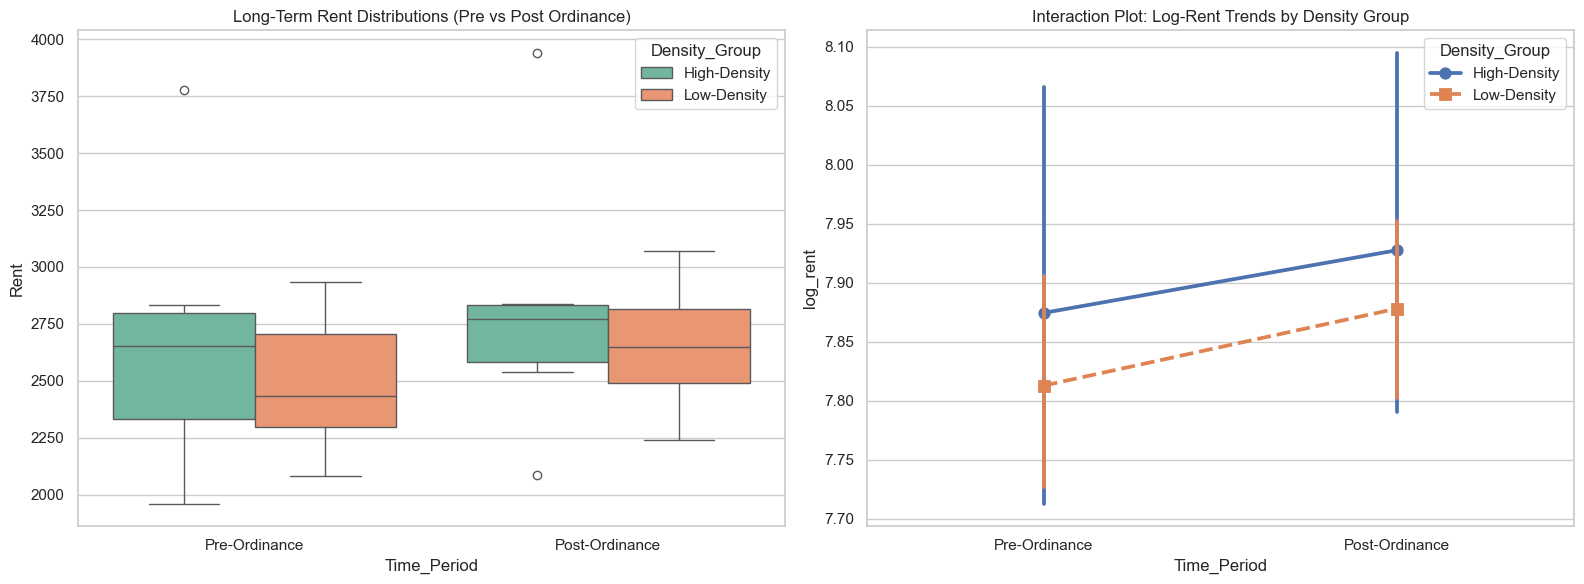

In [17]:
# Combine the 2023 and 2025 ZORI datasets
df_zori_2023['Time_Period'] = 'Pre-Ordinance'
df_zori_2025['Time_Period'] = 'Post-Ordinance'

df_rent = pd.concat([df_zori_2023, df_zori_2025], ignore_index=True)

# Clean Rent column (remove NaNs if any)
df_rent = df_rent.dropna(subset=['Rent'])

# Log-transform Rent for percentage interpretation and normality
df_rent['log_rent'] = np.log(df_rent['Rent'])

# Visualizing Long-Term Rents
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_rent, x='Time_Period', y='Rent', hue='Density_Group', palette='Set2', ax=axes[0])
axes[0].set_title('Long-Term Rent Distributions (Pre vs Post Ordinance)')

sns.pointplot(data=df_rent, x='Time_Period', y='log_rent', hue='Density_Group',
              markers=['o', 's'], linestyles=['-', '--'], ax=axes[1])
axes[1].set_title('Interaction Plot: Log-Rent Trends by Density Group')

plt.tight_layout()
plt.show()

## ZORI Multiple Linear Regression Modeling
We fit our final Ordinary Least Squares (OLS) model for `log_rent` to test if the interaction between `Density_Group` and `Time_Period` yields a statistically significant $p$-value ($p < 0.05$).

In [18]:
import statsmodels.formula.api as smf

# Set categorical baselines
df_rent['Density_Group'] = pd.Categorical(df_rent['Density_Group'], categories=['Low-Density', 'High-Density'])
df_rent['Time_Period'] = pd.Categorical(df_rent['Time_Period'], categories=['Pre-Ordinance', 'Post-Ordinance'])

# Define and fit the Rent OLS model
rent_formula = 'log_rent ~ Density_Group * Time_Period'
rent_model = smf.ols(formula=rent_formula, data=df_rent).fit()

print(rent_model.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                 -0.074
Method:                 Least Squares   F-statistic:                    0.4504
Date:                Sun, 07 Jun 2026   Prob (F-statistic):              0.720
Time:                        19:41:09   Log-Likelihood:                 10.755
No. Observations:                  25   AIC:                            -13.51
Df Residuals:                      21   BIC:                            -8.634
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

## ZORI Rent Analysis Results 
To determine whether the ordinance successfully combated housing affordability concerns, we tested if the reduction in short-term rentals translated into a decrease in long-term rent prices.

The OLS model for long-term rents yielded an interaction coefficient of -0.0122 with a p-value of 0.93. Therefore, we fail to reject the null hypothesis. There is no statistical evidence that long-term rents decreased disproportionately in high-density Airbnb ZIP codes after the ordinance was enacted. The data suggests that returning former Airbnb units to the long-term housing supply did not create a large enough supply shock to move the needle on overall rent prices in those specific ZIP codes.

## Final Project Summary
Our project aimed to evaluate the efficacy of San Diego's May 2023 STRO ordinance. By analyzing both the direct effect on short-term rental prices and the externalized effect on long-term housing costs (ZORI), we arrive at the following conclusions:

1.  Capping whole-home rentals did not cause the remaining Airbnbs in highly saturated markets to disproportionately raise their rates compared to less saturated areas.
2.  STRO's intended goal of improving housing affordability was not visible in the data. The influx of roughly half the city's short-term rentals back into the residential market was likely absorbed by San Diego's massive overarching housing deficit, resulting in no statistically significant drop in rent prices for the affected ZIP codes.
3. The ZORI dataset was aggregated at the ZIP code level, which is geographically broader than the neighborhood-level data provided by InsideAirbnb. This discrepancy in spatial resolution may have diluted highly localized rent changes. Future work could improve upon this analysis by acquiring parcel-level or exact-address rent histories to completely isolate the policy's effects.

---